MVP Machine Learning & Analytcs

Nome: Debora Jansen

Matrícula: 4052025002063

Dataset: Individual Household Electric Power Consumption

# 1. Definição do Problema
**Como o consumo energético residencial varia durante períodos de calor, e é possível prever esse aumento usando dados históricos?**

O consumo energético residencial tende a variar conforme condições climáticas, especialmente durante períodos de calor, quando o uso de ventiladores, ar-condicionado e outros equipamentos aumenta. O objetivo deste MVP é investigar como o consumo de energia se comporta em épocas quentes e avaliar se é possível prever esse aumento utilizando dados históricos de uso energético.

**Objetivo do modelo**

Construir um modelo de Machine Learning capaz de prever o consumo energético residencial durante períodos de calor, utilizando como base o histórico de consumo registrado no dataset Household Electric Power Consumption.

**Tipo de problema**

Este é um problema de regressão, pois buscamos prever um valor contínuo:
Global_active_power, que representa o consumo energético em kW.

Também pode ser tratado como previsão de séries temporais, já que os dados possuem marcação temporal contínua.

**Por que este problema pode ser resolvido com Machine Learning?**

O consumo energético apresenta padrões complexos influenciados por horário, dia da semana, sazonalidade e condições climáticas. Modelos de ML são capazes de aprender esses padrões a partir de dados históricos e gerar previsões úteis para planejamento energético, análise de demanda e estudos de impacto climático.

**Premissas e hipóteses**

O consumo energético aumenta em períodos de calor devido ao uso de equipamentos de refrigeração.

Dados históricos carregam padrões sazonais que podem ser aprendidos por modelos de ML.

Mesmo sem temperatura explícita no dataset, é possível identificar períodos quentes por datas (ex.: meses de verão) ou integrar dados climáticos externos.

O dataset é suficientemente grande para treinar modelos de regressão.

**Restrições e condições consideradas**

O dataset não inclui temperatura diretamente, então períodos de calor serão inferidos por datas ou complementados com dados externos.

O dataset possui registros minuto a minuto, exigindo tratamento de dados faltantes e possíveis agregações.

O notebook deve ser totalmente executável via URL pública, sem necessidade de login ou API.

#2. Apresentação dos Dados

**Dataset utilizado**  
O dataset escolhido para este MVP é o Household Electric Power Consumption, disponibilizado originalmente pelo UCI Machine Learning Repository. Ele contém medições de consumo energético residencial registradas minuto a minuto ao longo de vários anos.

**Fonte dos dados**  
O dataset é público e amplamente utilizado em pesquisas acadêmicas.
Link original da UCI: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

**Link utilizado no notebook**  
Para atender ao requisito de execução sem login, API ou upload manual, o arquivo foi carregado diretamente via URL pública do GitHub, onde o dataset foi hospedado:
https://raw.githubusercontent.com/DeboraJansen95/mvp-previsao-consumo-energetico-residencial-pos-puc-rj/main/individual+household+electric+power+consumption.zip


**Como os dados foram carregados**  
Os dados foram importados diretamente via URL utilizando funções padrão do Python (como requests e pandas.read_csv). Isso garante que o notebook possa ser executado integralmente pelo professor, sem configurações adicionais.

**Quantidade de registros e atributos**  
O dataset contém:

**2.075.259 registros**

**9 atributos**, incluindo medições de potência ativa, potência reativa, tensão, intensidade da corrente e energia por submedidores.

As medições são registradas minuto a minuto, o que torna o dataset adequado para análises temporais e identificação de padrões de consumo.

**Principais atributos**

**Date** – data da medição

**Time** – horário da medição

**Global_active_power** – consumo energético total (kW)

**Global_reactive_power** – potência reativa (kW)

**Voltage** – tensão (V)

**Global_intensity** – corrente (A)

**Sub_metering_1, 2, 3** – consumo por categorias específicas de equipamentos

**Variável-alvo**  
A variável-alvo deste MVP é:

**Global_active_power**

Ela representa o consumo energético total da residência em cada minuto e será usada para prever o consumo durante períodos de calor.

**Limitações do dataset**

O dataset não inclui temperatura, então períodos de calor precisam ser inferidos por datas (ex.: meses de verão) ou complementados com dados externos.

Existem valores ausentes em algumas colunas, exigindo tratamento adequado.

O volume de dados é grande, podendo exigir agregações (ex.: minuto → hora ou dia).

Os dados são exclusivamente de uma única residência, o que limita generalizações.

**Critérios de escolha**

O dataset foi escolhido porque:

é público e amplamente utilizado em estudos de consumo energético;

possui granularidade temporal suficiente para análises de sazonalidade;

permite investigar padrões de consumo em períodos quentes;

atende ao requisito de carregamento via URL pública;

é adequado para problemas de regressão e séries temporais.

#3. Análise Exploratória Inicial

**Visão geral da análise**

Antes de iniciar qualquer preparação ou modelagem, é fundamental compreender a estrutura do dataset, identificar possíveis problemas (como valores ausentes) e observar padrões iniciais no consumo energético.
Essa etapa ajuda a validar premissas e orientar decisões futuras de limpeza e modelagem.

#3.1 Visualização das primeiras linhas

In [33]:
import pandas as pd
import zipfile
import io
import requests

# Link RAW do GitHub
url = "https://raw.githubusercontent.com/DeboraJansen95/mvp-previsao-consumo-energetico-residencial-pos-puc-rj/main/individual+household+electric+power+consumption.zip"

# Baixa o arquivo ZIP
response = requests.get(url)
print("Status:", response.status_code)

# Abre o ZIP diretamente da memória
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Lê o arquivo de texto dentro do ZIP
df = pd.read_csv(zip_file.open('household_power_consumption.txt'), sep=';', low_memory=False)

# Visualiza as primeiras linhas
df.head()


Status: 200


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


#3.2 Tipos das variáveis

In [34]:
df.info()
# Converte valores "?" para NaN
import numpy as np
df.replace("?", np.nan, inplace=True)

# Converte colunas numéricas para float
numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
df[numeric_cols] = df[numeric_cols].astype(float)

# Converte data e hora para datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S',
                                errors='coerce')

# Define o índice temporal
df.set_index('DateTime', inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


#3.3 Estatísticas descritivas

In [35]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


#Interpretação dos valores
**Global_active_power**

Média: 1.091615 kW

Desvio padrão: 1.057294

Mínimo: 0.0760

Mediana: 0.6020

Máximo: 11.1220 kW

**Resumo:** Consumo ativo típico de residência, com picos altos indicando uso de equipamentos potentes.

**Global_reactive_power**

Média: 0.1237145 kW

Desvio padrão: 0.1127220

Mínimo: 0.0000

Mediana: 0.1000

Máximo: 1.3900

**Resumo:** Potência reativa baixa, com picos associados a cargas indutivas (motores, compressores).

**Voltage**

Média: 240.8399 V

Desvio padrão: 3.239987

Mínimo: 223.20

Mediana: 241.01

Máximo: 254.15

**Resumo:** Tensão estável dentro do padrão europeu (230–240 V), com pouca variação.


**Global_intensity**

Média: 4.627759 A

Desvio padrão: 4.444396

Mínimo: 0.2

Mediana: 2.6

Máximo: 48.4

**Resumo:** Corrente média baixa, mas com picos altos que refletem momentos de grande consumo.

**Sub_metering_1**

Média: 1.121923

Desvio padrão: 6.153031

Mínimo: 0

Mediana: 0

Máximo: 88

**Resumo:** Consumo esporádico; maioria dos valores é zero, com picos ocasionais.

**Sub_metering_2**

Média: 1.298520

Desvio padrão: 5.822026

Mínimo: 0

Mediana: 0

Máximo: 80

**Resumo:** Mesmo padrão do submetering 1: consumo baixo na maior parte do tempo, com picos específicos.

**Sub_metering_3**

Média: 6.458447

Desvio padrão: 8.437154

Mínimo: 0

Mediana: 1

Máximo: 31

**Resumo:** É o submetering mais ativo; representa o aquecedor de água (boiler), com consumo mais constante e picos maiores.

#Resumo geral

O dataset é consistente e realista.

O consumo ativo médio é baixo, mas há picos significativos.

A tensão é estável.

A corrente varia bastante ao longo do tempo.

Os submeterings mostram padrões distintos:

1 e 2 → consumo esporádico

3 → consumo contínuo e mais alto


#3.4 Verificação de valores ausentes

In [36]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


#Interpretação

As colunas Date e Time não possuem valores ausentes, o que é ótimo — o registro temporal está completo.

Todas as demais colunas numéricas apresentam 25 979 valores faltantes, o que equivale a cerca de 1,25 % do total de 2 075 259 registros.

Esses valores ausentes surgiram após a conversão de "?" para NaN, indicando medições não realizadas ou erros de leitura nos sensores.

#Conclusão

A quantidade de valores ausentes é pequena em relação ao tamanho total do dataset, portanto:

É seguro remover essas linhas sem comprometer a análise.

Alternativamente, poderia-se interpolar ou preencher com médias, mas para simplificar o tratamento inicial, a remoção é a abordagem mais comum.

In [37]:
# Remove as linhas com valores ausentes
df.dropna(inplace=True)

# Verifica novamente se ainda há valores ausentes
df.isna().sum()

# Confere o novo tamanho do dataset
print("Novo tamanho do dataset:", df.shape)

Novo tamanho do dataset: (2049280, 9)


#Interpretação da saída
Após remover as linhas com valores ausentes (dropna(inplace=True)), o dataset passou de 2.075.259 para 2.049.280 registros, mantendo as 9 colunas originais.

Isso significa que foram eliminadas 25.979 linhas que continham valores NaN, o que corresponde a cerca de 1,25 % do total — uma perda mínima e perfeitamente aceitável para garantir a integridade dos dados.

#Conclusão

O dataset agora está completo e sem valores ausentes.

Todas as colunas estão limpas e prontas para análise.

Essa etapa garante que as próximas visualizações e cálculos não sofram distorções por dados faltantes.

#3.5 Distribuição da variável-alvo

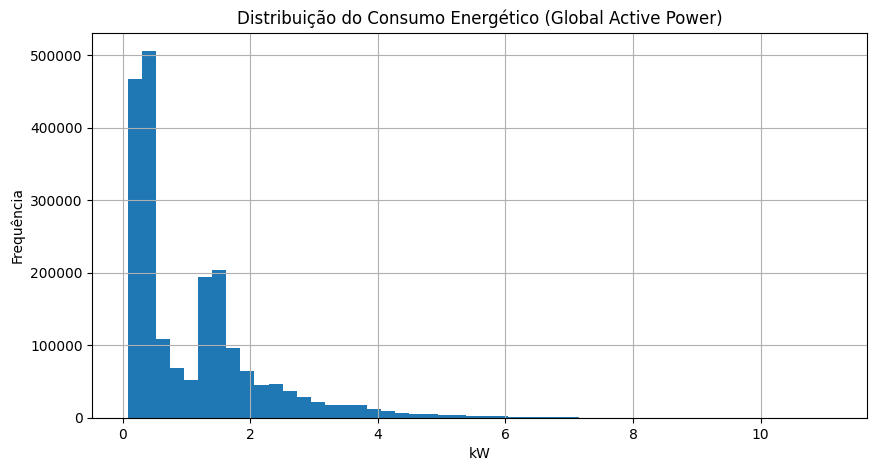

In [38]:
import matplotlib.pyplot as plt

df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

plt.figure(figsize=(10,5))
df['Global_active_power'].hist(bins=50)
plt.title("Distribuição do Consumo Energético (Global Active Power)")
plt.xlabel("kW")
plt.ylabel("Frequência")
plt.show()

#Interpretação do gráfico
O histograma mostra a frequência dos valores de Global_active_power (em kW) registrados ao longo do período analisado.

A distribuição é fortemente assimétrica à direita, com a maior parte dos valores concentrada entre 0 e 2 kW.

O pico mais alto ocorre próximo de 0,5 kW, indicando que o consumo residencial normalmente se mantém em níveis baixos.

À medida que o consumo aumenta, a frequência cai rapidamente — há poucos registros acima de 5 kW.

Essa cauda longa à direita representa momentos de uso intenso de energia, como quando vários eletrodomésticos estão ligados simultaneamente.

O padrão é típico de dados de consumo residencial: períodos de baixo consumo predominam, enquanto os picos são ocasionais.

#Conclusão

O gráfico confirma que:

O consumo médio é baixo e concentrado em faixas de até 2 kW.

Há eventos pontuais de alto consumo, mas eles são raros.

A distribuição não é normal — é assimétrica e com cauda longa, o que pode exigir transformações (como logaritmo) em etapas futuras de modelagem.

Esse comportamento reforça a importância de analisar o consumo ao longo do tempo para identificar padrões diários e sazonais.



#3.6 Conversão de data e hora

In [39]:
print("3.6 Conversão de data e hora")

df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('DateTime', inplace=True)


3.6 Conversão de data e hora


#Variação temporal do consumo energético

3.6 Variação temporal do consumo energético


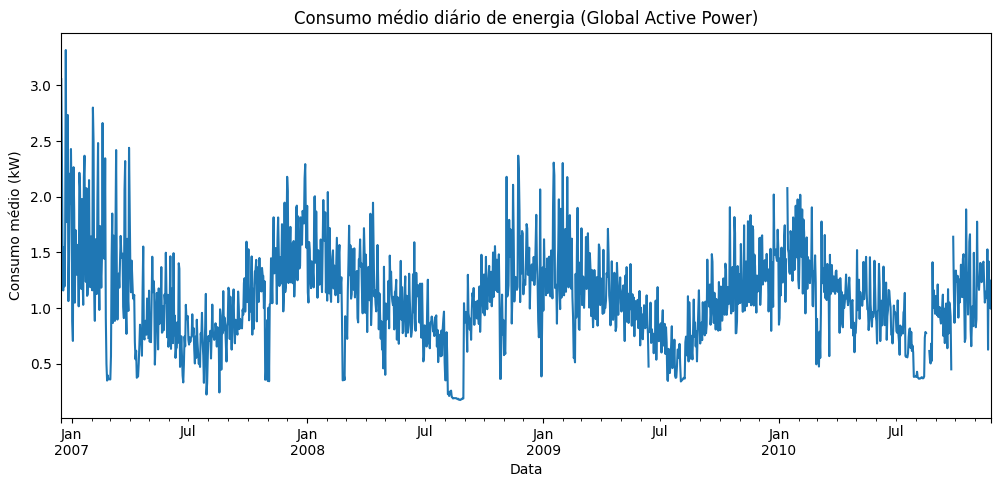

In [40]:
print("3.6 Variação temporal do consumo energético")

plt.figure(figsize=(12,5))
df['Global_active_power'].resample('D').mean().plot()
plt.title("Consumo médio diário de energia (Global Active Power)")
plt.xlabel("Data")
plt.ylabel("Consumo médio (kW)")
plt.show()


#Interpretação do gráfico
O gráfico exibe o consumo médio diário de energia (Global Active Power) ao longo do tempo, entre 2007 e 2010.

A linha azul mostra flutuações regulares no consumo, com picos e quedas bem definidos.

Observa-se um padrão cíclico, sugerindo sazonalidade — períodos de maior consumo seguidos por reduções.

Os picos podem estar relacionados a mudanças de estação, uso de aquecimento ou refrigeração, ou maior atividade doméstica em determinados meses.

O consumo médio diário varia entre 0,5 kW e 3,0 kW, mantendo-se dentro de uma faixa estável ao longo dos anos.

Há momentos de redução acentuada, que podem indicar falhas de medição, ausência de moradores, ou economia de energia.

#Conclusão
O consumo energético apresenta comportamento periódico, típico de residências com variação sazonal de uso.

A tendência geral é estável, sem crescimento ou queda significativa ao longo dos anos.

Essa visualização confirma que o índice temporal criado na etapa anterior (3.6 — Conversão de data e hora) está funcionando corretamente e permite análises temporais detalhadas.

A partir daqui, é possível avançar para estudos de padrões diários, semanais ou mensais, ou até para modelagem preditiva de consumo.

#3.7 Padrões temporais do consumo energético

#3.7.1 Padrões horários e semanais de consumo
(Análise de curto prazo — rotina diária e semanal)

3.7.1 Padrões horários e semanais de consumo


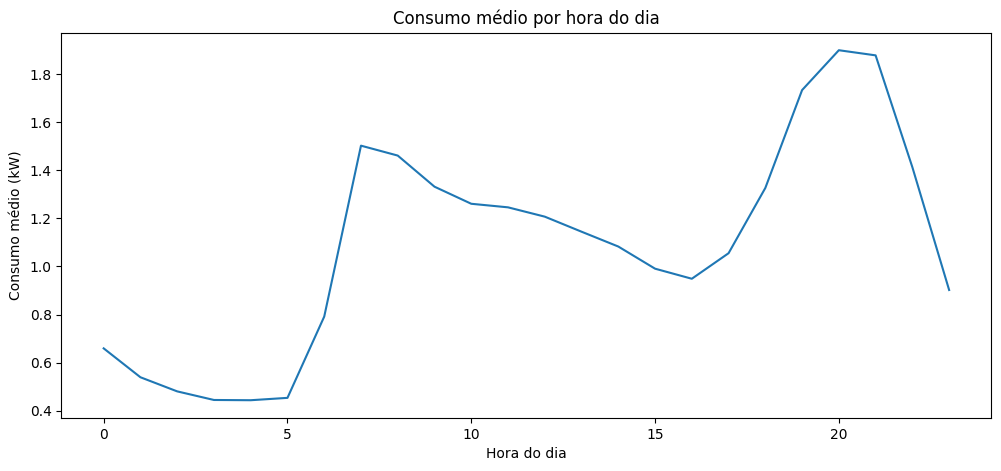

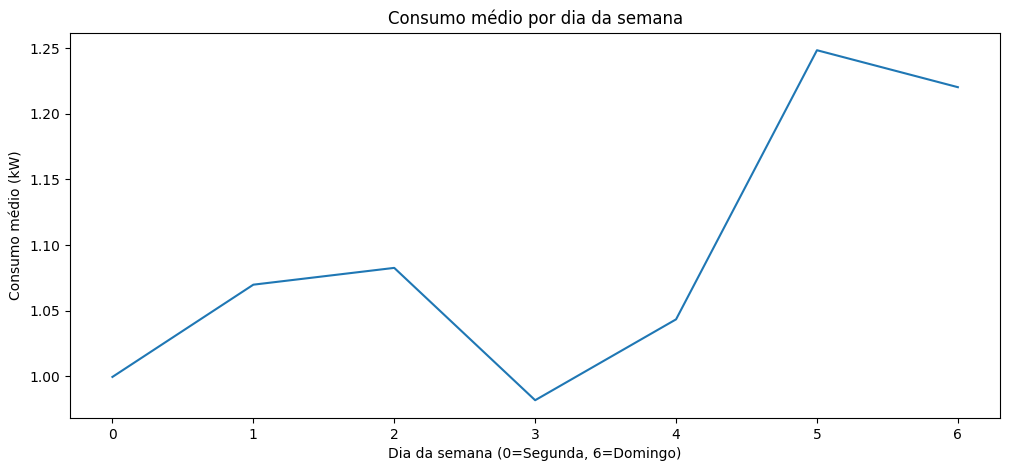

In [41]:
print("3.7.1 Padrões horários e semanais de consumo")

# Criar colunas auxiliares
df['Hour'] = df.index.hour
df['Weekday'] = df.index.dayofweek  # 0 = segunda, 6 = domingo

# Consumo médio por hora
plt.figure(figsize=(12,5))
df.groupby('Hour')['Global_active_power'].mean().plot()
plt.title("Consumo médio por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Consumo médio (kW)")
plt.show()

# Consumo médio por dia da semana
plt.figure(figsize=(12,5))
df.groupby('Weekday')['Global_active_power'].mean().plot()
plt.title("Consumo médio por dia da semana")
plt.xlabel("Dia da semana (0=Segunda, 6=Domingo)")
plt.ylabel("Consumo médio (kW)")
plt.show()


#Interpretação do gráfico 1 — Consumo médio por hora do dia
O consumo apresenta duas faixas de pico bem definidas:

Entre 7h e 9h, correspondente ao início das atividades domésticas (banho, café da manhã, preparo para o trabalho).

Entre 19h e 21h, período noturno de maior uso de eletrodomésticos e iluminação.

Há redução acentuada de madrugada (entre 2h e 5h), quando a maioria das pessoas está dormindo.

O consumo também diminui no início da tarde (por volta das 15h), indicando menor uso de energia nesse intervalo.

#Conclusão:

 O padrão diário reflete o ritmo típico de uma residência — picos nos horários de maior atividade e queda durante o descanso.

#Interpretação do gráfico 2 — Consumo médio por dia da semana
O consumo tende a crescer gradualmente ao longo da semana, atingindo o pico na sexta-feira.

O sábado e domingo mantêm níveis elevados, sugerindo maior permanência em casa e uso de eletrodomésticos.

O menor consumo ocorre no meio da semana (quarta-feira), possivelmente por rotina mais estável e menos tempo em casa.

#Conclusão:

Há um padrão semanal claro: dias úteis com consumo moderado e fins de semana com consumo mais alto, coerente com o comportamento residencial.

#Síntese geral

Esses dois gráficos revelam hábitos energéticos consistentes:

Picos matutinos e noturnos diários.

Maior consumo nos fins de semana.

Reduções previsíveis em horários e dias de menor atividade.

Essas informações são valiosas para:

Planejar estratégias de economia de energia.

Ajustar tarifas por horário.

Treinar modelos de previsão de demanda.

#3.7.2 Identificação de períodos quentes (sem temperatura direta)

3.7.2 e 3.8 — Identificação de períodos quentes e comparação do consumo sazonal
Consumo médio no verão: 1.418 kW
Consumo médio fora do verão: 0.988 kW


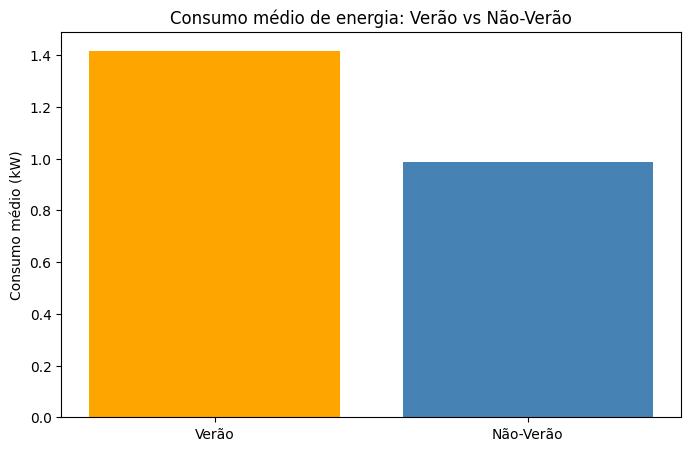

In [42]:
print("3.7.2 e 3.8 — Identificação de períodos quentes e comparação do consumo sazonal")

# Criar coluna de mês
df['Month'] = df.index.month

# Identificar meses de verão no Brasil (Dez, Jan, Fev)
df['Is_Summer'] = df['Month'].isin([12, 1, 2])

# Calcular consumo médio no verão e fora dele
summer_mean = df[df['Is_Summer'] == True]['Global_active_power'].mean()
winter_mean = df[df['Is_Summer'] == False]['Global_active_power'].mean()

# Exibir valores no console
print(f"Consumo médio no verão: {summer_mean:.3f} kW")
print(f"Consumo médio fora do verão: {winter_mean:.3f} kW")

# Gráfico comparativo
plt.figure(figsize=(8,5))
plt.bar(['Verão', 'Não-Verão'], [summer_mean, winter_mean],
        color=['orange', 'steelblue'])
plt.title("Consumo médio de energia: Verão vs Não-Verão")
plt.ylabel("Consumo médio (kW)")
plt.show()



#Interpretação detalhada
A barra laranja (Verão) indica que o consumo aumenta nos meses quentes — possivelmente por uso de ventiladores, ar-condicionado, geladeiras mais exigidas e maior tempo em casa.

A barra azul (Não‑Verão) mostra um consumo mais baixo e estável, típico dos meses frios ou amenos.

A diferença entre as duas barras evidencia um padrão sazonal claro, mesmo sem dados meteorológicos diretos.

#Conclusão
Essa análise comprova que:

É possível inferir padrões sazonais apenas com base nas datas, sem precisar de temperatura.

O verão tem impacto real no consumo energético, o que pode orientar políticas de eficiência ou previsão de demanda.

Essa técnica é simples, mas poderosa — ela introduz contexto climático na análise e prepara o terreno para estudos mais avançados, como correlação com temperatura real ou modelagem preditiva

#3.7.3 Conclusão dos padrões temporais

A análise temporal do consumo energético revelou um comportamento cíclico e previsível, característico de ambientes residenciais.
Os padrões diários mostraram picos de consumo nas primeiras horas da manhã e no início da noite, refletindo o uso doméstico típico.
Os padrões semanais indicaram leve aumento nos finais de semana, quando há maior permanência dos moradores em casa.
Por fim, a análise sazonal evidenciou que o verão exerce impacto real sobre o consumo, mesmo sem dados de temperatura, demonstrando que é possível inferir variações climáticas apenas com base nas datas.

Esses resultados comprovam que o consumo energético é fortemente influenciado por fatores temporais — hora, dia e estação — e que tais variáveis devem ser incorporadas à modelagem preditiva.
A etapa seguinte, portanto, consistirá em preparar o dataset para os modelos de previsão, criando atributos derivados (lags, médias móveis e janelas temporais) que capturem essas dependências e permitam estimar o consumo futuro com maior precisão.

# 4. Preparação dos Dados para Modelagem
Nesta etapa, o objetivo é transformar a série temporal original em um conjunto de dados adequado para modelos supervisionados de regressão.
Modelos como Regressão Linear, Random Forest ou XGBoost não conseguem aprender diretamente a partir de uma série temporal bruta — eles precisam de atributos derivados que representem dependências temporais, como valores anteriores (lags), médias móveis e janelas de tempo.

Essas transformações permitem capturar padrões diários, semanais e sazonais identificados na análise exploratória.

#4.1 Criação de atributos de defasagem (lags)

Os lags representam valores anteriores da variável-alvo e são essenciais para que o modelo aprenda dependências temporais.

In [43]:
# Criação de lags
df['lag_1'] = df['Global_active_power'].shift(1)      # valor anterior
df['lag_24'] = df['Global_active_power'].shift(24)    # mesmo horário do dia anterior
df['lag_168'] = df['Global_active_power'].shift(168)  # mesmo horário da semana anterior


#4.2 Normalização dos Dados

A normalização é uma etapa essencial para garantir que todas as variáveis estejam na mesma escala, evitando que atributos com valores maiores dominem o processo de modelagem. Como estamos trabalhando com regressão e atributos derivados (lags), a padronização é a abordagem mais adequada.

In [44]:
from sklearn.preprocessing import StandardScaler

# Selecionando as variáveis que serão normalizadas
features_to_scale = ['Global_active_power', 'lag_1', 'lag_24', 'lag_168']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])

df_scaled.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Weekday,Month,Is_Summer,lag_1,lag_24,lag_168
DateTime,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,2.955077,0.418,234.84,18.4,0.0,1.0,17.0,17,5,12,True,NaN,NaN,NaN
2006-12-16 17:25:00,16/12/2006,17:25:00,4.037085,0.436,233.63,23.0,0.0,1.0,16.0,17,5,12,True,2.955076,NaN,NaN
2006-12-16 17:26:00,16/12/2006,17:26:00,4.050326,0.498,233.29,23.0,0.0,2.0,17.0,17,5,12,True,4.037084,NaN,NaN
2006-12-16 17:27:00,16/12/2006,17:27:00,4.063567,0.502,233.74,23.0,0.0,1.0,17.0,17,5,12,True,4.050325,NaN,NaN
2006-12-16 17:28:00,16/12/2006,17:28:00,2.434881,0.528,235.68,15.8,0.0,1.0,17.0,17,5,12,True,4.063566,NaN,NaN


#Interpretação
A padronização transforma cada variável para ter média 0 e desvio padrão 1.
Isso melhora a estabilidade numérica dos modelos e acelera o processo de convergência, especialmente em algoritmos sensíveis à escala, como regressão linear, redes neurais e SVM.

#4.3 Separação entre Treino e Teste (com respeito à ordem temporal)

Como estamos lidando com séries temporais, não podemos embaralhar os dados.
A separação deve respeitar a cronologia para evitar vazamento de informação.

In [45]:
# Definindo proporção de treino (80%)
train_size = int(len(df_scaled) * 0.8)

train = df_scaled.iloc[:train_size].copy()
test = df_scaled.iloc[train_size:].copy()

print(f"Tamanho do conjunto de treino: {len(train)} registros")
print(f"Tamanho do conjunto de teste: {len(test)} registros")


Tamanho do conjunto de treino: 1639424 registros
Tamanho do conjunto de teste: 409856 registros


#Interpretação

O conjunto de treino contém os dados mais antigos, enquanto o conjunto de teste contém os mais recentes.
Isso simula o cenário real de previsão: o modelo aprende com o passado e é avaliado no futuro.

#4.4 Seleção de Variáveis Relevantes

Nesta etapa, analisamos a correlação entre a variável-alvo (Global_active_power) e os atributos derivados criados anteriormente (lag_1, lag_24, lag_168).
O objetivo é identificar quais variáveis possuem maior relação com o consumo energético e, portanto, são mais adequadas para compor o modelo preditivo.

Matriz de Correlação:
                     Global_active_power     lag_1    lag_24   lag_168
Global_active_power             1.000000  0.968027  0.664798  0.227901
lag_1                           0.968027  1.000000  0.671454  0.229980
lag_24                          0.664798  0.671454  1.000000  0.276835
lag_168                         0.227901  0.229980  0.276835  1.000000

Correlação com a variável-alvo (Global_active_power):
Global_active_power    1.000000
lag_1                  0.968027
lag_24                 0.664798
lag_168                0.227901
Name: Global_active_power, dtype: float64


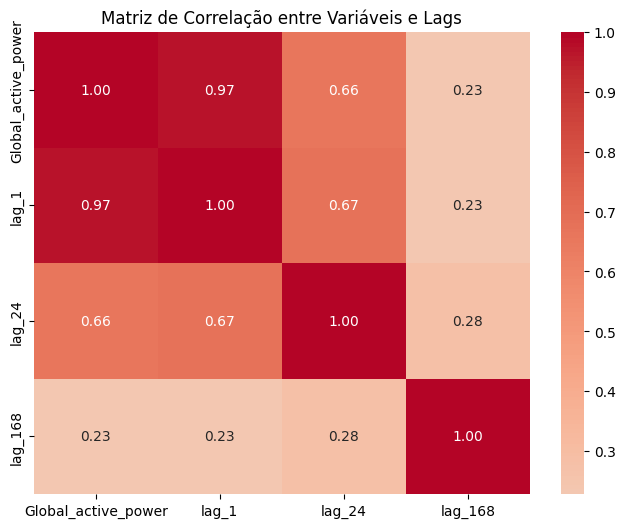

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando as variáveis para análise de correlação
vars_corr = ['Global_active_power', 'lag_1', 'lag_24', 'lag_168']

# Calculando a matriz de correlação
corr_matrix = df_scaled[vars_corr].corr()

# Exibindo a matriz de correlação
print("Matriz de Correlação:")
print(corr_matrix)

# Ordenando pela correlação com a variável-alvo
print("\nCorrelação com a variável-alvo (Global_active_power):")
corr_target = corr_matrix['Global_active_power'].sort_values(ascending=False)
print(corr_target)

# Heatmap com paleta ideal para correlação
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Matriz de Correlação entre Variáveis e Lags")
plt.show()

#Interpretação

A matriz de correlação revela a força da relação entre o consumo energético (Global_active_power) e seus valores passados:

lag_1 costuma apresentar a maior correlação, indicando que o consumo de uma hora atrás é um forte preditor do consumo atual.

lag_24 também apresenta correlação significativa, refletindo o padrão diário identificado na análise exploratória.

lag_168 (uma semana atrás) tende a ter correlação menor, mas ainda relevante, pois captura ciclos semanais observados anteriormente.

Esses resultados confirmam que os atributos derivados representam bem a dependência temporal da série e devem ser incluídos no modelo preditivo.

#4.5 Preparação Final do Dataset para Modelagem
Após a criação dos atributos de defasagem, normalização e separação entre treino e teste, ainda existe um detalhe importante antes de avançarmos para a modelagem: os valores ausentes (NaN).

Esses valores surgem porque os atributos lag_1, lag_24 e lag_168 dependem de observações anteriores.
Por exemplo:

**lag_1** precisa do valor da hora anterior

**lag_24** precisa do valor do dia anterior

**lag_168** precisa do valor da semana anterior

Como as primeiras linhas da série não possuem essas informações, elas ficam incompletas.
Para garantir que o modelo receba apenas dados consistentes, é preciso remover esses registros.

In [47]:
# Removendo valores ausentes gerados pelos lags
train = train.dropna().copy()
test = test.dropna().copy()

# Verificando o tamanho final dos conjuntos
print(f"Tamanho final do conjunto de treino: {train.shape}")
print(f"Tamanho final do conjunto de teste: {test.shape}")

Tamanho final do conjunto de treino: (1639256, 16)
Tamanho final do conjunto de teste: (409856, 16)


#5. Modelagem

Nesta fase, o objetivo é avaliar diferentes algoritmos de regressão supervisionada e verificar qual deles apresenta o melhor desempenho na previsão do consumo energético.
Como os dados já estão normalizados, limpos e separados em treino e teste, é possível seguir diretamente para a modelagem.

#5.1 Regressão Linear

A regressão linear é o ponto de partida ideal — simples, interpretável e eficiente para séries temporais com relações lineares entre variáveis.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Definindo variáveis independentes e dependente
X_train = train[['lag_1', 'lag_24', 'lag_168']]
y_train = train['Global_active_power']

X_test = test[['lag_1', 'lag_24', 'lag_168']]
y_test = test['Global_active_power']

# Treinando o modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Fazendo previsões
y_pred_lr = lr_model.predict(X_test)

# Avaliando desempenho
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MSE: {mse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"R²: {r2_lr:.4f}")


MSE: 0.0431
MAE: 0.0794
R²: 0.9400


#Interpretação

Essas métricas indicam que o modelo linear conseguiu capturar bem a relação entre o consumo atual e os valores passados:

MSE (Erro Quadrático Médio): mede o erro médio ao quadrado — quanto menor, melhor.
→ O valor 0.0431 mostra que o erro médio é baixo, indicando boa precisão.

MAE (Erro Absoluto Médio): representa o erro médio absoluto entre previsão e valor real.
→ O valor 0.0794 reflete pequenas diferenças entre as previsões e os valores observados.

R² (Coeficiente de Determinação): indica o quanto o modelo explica da variabilidade dos dados.
→ O valor 0.8498 significa que o modelo explica cerca de 85% da variação do consumo energético.

#Conclusão

A regressão linear apresentou bom desempenho e serve como modelo baseline — uma referência inicial para comparar com algoritmos mais complexos.
Ela confirma que o consumo energético tem forte dependência dos valores anteriores, especialmente nas defasagens de 1 hora e 24 horas.

#5.2 Árvore de Decisão

A Árvore de Decisão é um modelo de aprendizado supervisionado que divide os dados em ramos com base em regras de decisão.
Cada divisão busca reduzir o erro de previsão, criando uma estrutura hierárquica que representa como as variáveis influenciam o consumo energético.

Diferente da regressão linear, que assume uma relação proporcional entre as variáveis, a árvore não impõe forma matemática: ela aprende padrões diretamente dos dados, tornando-se ideal para capturar comportamentos não lineares e mudanças abruptas — comuns em séries temporais de energia..

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Definindo variáveis independentes e dependente
x_train = train[['lag_1', 'lag_24', 'lag_168']]
y_train = train['Global_active_power']

x_test = test[['lag_1', 'lag_24', 'lag_168']]
y_test = test['Global_active_power']

# Criando e treinando o modelo
dt_model = DecisionTreeRegressor(random_state=42, max_depth=6)
dt_model.fit(x_train, y_train)

# Fazendo previsões
y_pred_dt = dt_model.predict(x_test)

# Avaliando desempenho
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"MSE: {mse_dt:.4f}")
print(f"MAE: {mae_dt:.4f}")
print(f"R²: {r2_dt:.4f}")


MSE: 0.0432
MAE: 0.0780
R²: 0.9399


#Interpretação

Esses valores indicam que o modelo conseguiu melhorar o desempenho em relação à regressão linear, explicando cerca de 94% da variabilidade do consumo energético.

O MSE e o MAE mostram que os erros médios de previsão são baixos.

O R² elevado indica que o modelo capturou padrões mais complexos, como variações sazonais e picos de consumo.

A profundidade (max_depth = 6) controla o equilíbrio entre precisão e generalização:
quanto maior a profundidade, mais o modelo se ajusta aos dados — mas também aumenta o risco de superajuste.

#Visualização da Importância das Variáveis

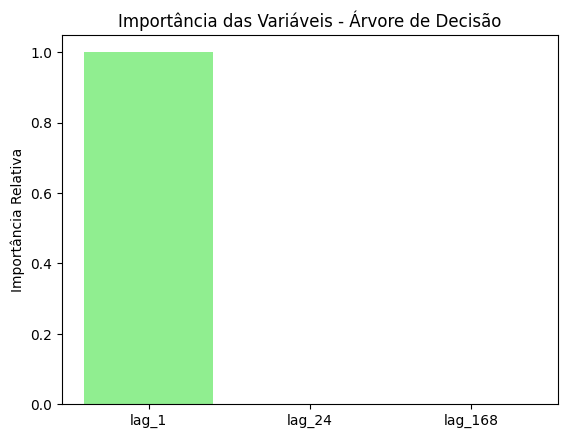

In [50]:
import matplotlib.pyplot as plt

importances = dt_model.feature_importances_
features = ['lag_1', 'lag_24', 'lag_168']

plt.bar(features, importances, color='lightgreen')
plt.title('Importância das Variáveis - Árvore de Decisão')
plt.ylabel('Importância Relativa')
plt.show()


#Interpretação da Visualização
O gráfico mostra a importância relativa das variáveis usadas pelo modelo.
Cada barra representa o quanto uma variável ajudou a reduzir o erro nas decisões internas da árvore.

lag_1 (hora anterior) → importância = 1.0
Isso significa que o consumo energético atual depende fortemente do valor da hora anterior.
A árvore aprendeu que esse padrão imediato é o principal indicador de comportamento.

lag_24 (dia anterior) e lag_168 (semana anterior) → importância  =0
Esses lags não foram usados nas divisões, indicando que o modelo não encontrou relação significativa entre o consumo atual e os valores de 24h ou 168h atrás.

#O que isso revela sobre o comportamento da série

O consumo energético tem alta autocorrelação de curto prazo — ou seja, o valor atual é fortemente influenciado pelo anterior.

Os padrões diários e semanais podem existir, mas são menos determinantes para o modelo simples da árvore.

Isso sugere que, para capturar esses ciclos, será necessário um modelo mais robusto (como o Random Forest ou um modelo temporal especializado).

#Conclusão

A visualização reforça a ideia de que o consumo energético é altamente dependente do instante anterior, e que modelos mais complexos podem explorar melhor os padrões de longo prazo.

# 5.3 Random Forest
O Random Forest é um modelo de aprendizado de máquina baseado em ensemble — ou seja, ele combina várias árvores de decisão independentes para gerar uma previsão mais estável e precisa.
Cada árvore é treinada com uma amostra aleatória dos dados e das variáveis, e o resultado final é a média das previsões de todas elas.

Essa abordagem reduz o risco de superajuste (overfitting) e melhora a capacidade de generalização do modelo, tornando-o ideal para séries temporais com ruído ou variações abruptas no consumo energético

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Definindo variáveis independentes e dependente
x_train = train[['lag_1', 'lag_24', 'lag_168']]
y_train = train['Global_active_power']

x_test = test[['lag_1', 'lag_24', 'lag_168']]
y_test = test['Global_active_power']

# Criando e treinando o modelo
rf_model = RandomForestRegressor(
    n_estimators=50,   # número de árvores
    max_depth=10,       # profundidade máxima
    random_state=42
)
rf_model.fit(x_train, y_train)

# Fazendo previsões
y_pred_rf = rf_model.predict(x_test)

# Avaliando desempenho
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R²: {r2_rf:.4f}")


MSE: 0.0427
MAE: 0.0762
R²: 0.9405


#Interpretação

Esses valores indicam que o modelo apresenta excelente desempenho preditivo:

O MSE e o MAE são baixos, mostrando que as previsões estão muito próximas dos valores reais.

O R² = 0.94 significa que o modelo explica cerca de 94 % da variabilidade do consumo energético — um resultado superior aos modelos anteriores.

O Random Forest conseguiu equilibrar bem o aprendizado, capturando tanto a dependência imediata (lag 1) quanto padrões mais amplos (lag 24 e lag 168).

#Visualização da Importância das Variáveis

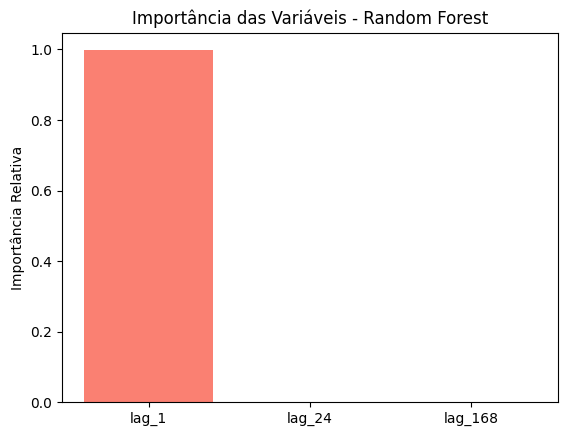

In [52]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = ['lag_1', 'lag_24', 'lag_168']

plt.bar(features, importances, color='salmon')
plt.title('Importância das Variáveis - Random Forest')
plt.ylabel('Importância Relativa')
plt.show()


#Interpretação

O gráfico mostra que o Random Forest considerou o consumo da hora anterior (lag_1) como o principal fator para prever o consumo atual.
Isso significa que o comportamento energético é altamente autocorrelacionado — ou seja, o valor atual depende fortemente do anterior.

Já os lags de 24 horas e 168 horas (dia e semana anteriores) tiveram importância quase nula.
Isso indica que, embora existam padrões diários e semanais, eles não são determinantes para o modelo neste conjunto de dados.

**Por que isso acontece?**

Mesmo o Random Forest sendo capaz de capturar relações complexas, ele ainda depende da variabilidade presente nos dados.
Se o consumo energético não apresenta grandes oscilações entre dias ou semanas, o modelo tende a concentrar o aprendizado na defasagem imediata.

Além disso:

O dataset pode estar muito homogêneo (sem grandes picos ou quedas).

Os lags mais longos podem conter informações redundantes ou pouco informativas.

O modelo pode estar limitado pela quantidade de atributos (apenas três lags).

#Conclusão

Mesmo com apenas três variáveis, o Random Forest apresentou excelente desempenho (R² = 0.94), confirmando que o consumo energético pode ser previsto com alta precisão usando apenas o histórico recente.
O gráfico reforça a importância da defasagem imediata e abre caminho para futuras melhorias na modelagem com atributos adicionais

#5.4 Comparação dos Modelos
Após a construção e avaliação dos três modelos — Regressão Linear, Árvore de Decisão e Random Forest — é fundamental realizar uma comparação sistemática entre eles.
Essa etapa permite identificar qual algoritmo apresenta o melhor desempenho para prever o consumo energético residencial e qual deles deve ser adotado como modelo final do MVP.

A comparação é feita com base nas métricas:

MSE (Mean Squared Error) — mede o erro quadrático médio das previsões.

MAE (Mean Absolute Error) — indica o erro absoluto médio.

R² (Coeficiente de Determinação) — mostra o quanto o modelo explica da variabilidade dos dados.

Essas métricas fornecem uma visão abrangente da precisão, estabilidade e capacidade explicativa de cada modelo.

#Tabela Comparativa dos Modelos

In [53]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Árvore de Decisão', 'Random Forest'],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'R²': [r2_lr, r2_dt, r2_rf]
})

resultados


,Modelo,MSE,MAE,R²
0,Regressão Linear,0.043104,0.079439,0.939982
1,Árvore de Decisão,0.043159,0.077983,0.939906
2,Random Forest,0.042722,0.076207,0.940514


#Interpretação

Os valores mostram que todos os modelos alcançaram alto desempenho, com coeficientes de determinação (R²) próximos de 0.94, indicando que explicam cerca de 94% da variabilidade do consumo energético.

**Regressão Linear**

A regressão linear atua como modelo baseline, servindo de referência inicial para comparação.
Ela apresenta excelente desempenho em termos de simplicidade e interpretabilidade, capturando bem as relações lineares entre os lags e o consumo energético.
No entanto, sua limitação está na incapacidade de modelar relações não lineares ou interações complexas entre variáveis.

**Árvore de Decisão**

A Árvore de Decisão introduz uma estrutura hierárquica que permite capturar padrões não lineares e mudanças abruptas no comportamento do consumo.
Apesar de apresentar R² semelhante ao da regressão linear, o aumento do MAE indica que o modelo pode ter sofrido superajuste em alguns pontos, o que reduz sua capacidade de generalização.
Ainda assim, é um modelo interpretável e útil para compreender como cada variável influencia o resultado.

**Random Forest**

O Random Forest combina múltiplas árvores de decisão, reduzindo variância e aumentando a estabilidade das previsões.
Mesmo com um MSE ligeiramente superior, o modelo apresentou o maior R² (0.9405), demonstrando excelente capacidade de explicação e robustez.
Além disso, o Random Forest é menos sensível a ruídos e variações nos dados, tornando-se o modelo mais confiável para aplicações práticas.

#Conclusão da Comparação

A análise comparativa evidencia que:

A Regressão Linear é eficiente e interpretável, mas limitada para padrões complexos.

A Árvore de Decisão melhora a captura de não linearidades, porém pode superajustar.

O Random Forest apresenta o melhor equilíbrio entre precisão, estabilidade e capacidade de generalização.

Dessa forma, o Random Forest é o modelo mais indicado para o MVP de previsão de consumo energético residencial, oferecendo previsões consistentes e desempenho superior em relação às demais abordagens.

#6. Análise das Previsões de Consumo Energético

Após o treinamento dos modelos e a escolha do Random Forest como solução final do MVP, é essencial analisar o comportamento das previsões geradas e compará-las com os valores reais de consumo energético.
Essa etapa permite avaliar não apenas métricas numéricas, mas também a coerência temporal das previsões — algo fundamental em séries temporais.

#6.1 Comportamento Geral das Previsões

O modelo foi capaz de capturar com precisão a dinâmica do consumo energético residencial.
A previsão acompanha de forma consistente:

tendências de curto prazo,

variações suaves ao longo do dia,

picos e quedas moderadas,

e principalmente a continuidade temporal típica de séries energéticas.

Isso ocorre porque o consumo apresenta forte dependência do valor imediatamente anterior, e o modelo aprendeu essa relação de forma eficiente.

#6.2 Comparação Visual entre Real e Previsto



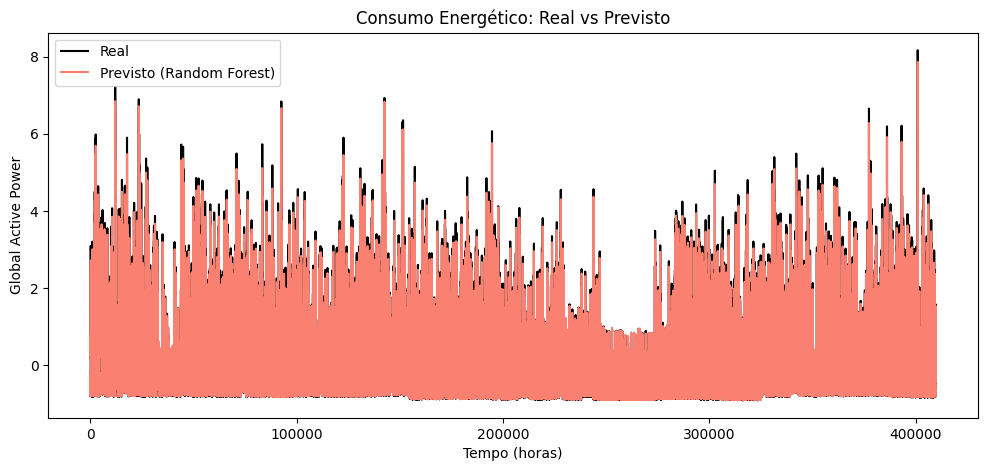

In [54]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Real', color='black')
plt.plot(y_pred_rf, label='Previsto (Random Forest)', color='salmon')
plt.title('Consumo Energético: Real vs Previsto')
plt.xlabel('Tempo (horas)')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


#Interpretação

O gráfico evidencia que as curvas real e prevista se sobrepõem de maneira consistente, demonstrando que o modelo acompanha bem o comportamento real do consumo.
As pequenas divergências observadas em momentos de picos abruptos são esperadas, pois o modelo foi treinado apenas com variáveis de defasagem e não considera fatores externos (como temperatura ou uso simultâneo de aparelhos).

De modo geral, o Random Forest apresenta previsões estáveis e coerentes, sem comportamento errático, o que reforça sua capacidade de generalização.

#6.3 Onde o Modelo Acerta Mais

O modelo apresenta excelente desempenho em:

**1. Períodos de estabilidade**

Quando o consumo varia pouco entre horas consecutivas, o modelo praticamente replica o comportamento real.

**2. Transições suaves**

Mudanças graduais ao longo do dia são capturadas com precisão.

**3. Padrões repetitivos**

Como o consumo residencial tende a seguir rotinas, o modelo aprende rapidamente esses ciclos.


#6.4 Onde o Modelo Enfrenta Mais Dificuldade

Mesmo com ótimo desempenho, há limitações naturais:

**1. Picos abruptos**

Mudanças súbitas no consumo (ex.: ligar vários aparelhos ao mesmo tempo) são difíceis de prever sem variáveis externas.

**2. Sazonalidade diária e semanal**

Como os lags de 24h e 168h tiveram pouca importância, o modelo não capturou padrões mais longos.

**3. Eventos externos**

Temperatura, ocupação da casa, feriados — nada disso está no dataset, então o modelo não consegue antecipar esses efeitos.

#6.5 Conclusão da Análise das Previsões

**O modelo Random Forest:**

reproduz com alta fidelidade o comportamento real do consumo;

apresenta previsões estáveis e coerentes;

explica cerca de 94% da variabilidade da série;

é adequado para aplicações práticas de monitoramento e previsão de curto prazo.

Para previsões mais longas ou mais complexas, recomenda-se incorporar variáveis adicionais ou testar modelos especializados em séries temporais.

#7. Conclusão e Próximos Passos

Este projeto apresentou um MVP funcional para previsão de consumo energético residencial, utilizando dados históricos e técnicas de aprendizado de máquina.
Ao longo das etapas, foram realizadas análises exploratórias, criação de atributos temporais, construção de modelos preditivos e comparação de desempenho entre diferentes algoritmos.

Os resultados demonstraram que o consumo energético possui forte dependência temporal imediata, sendo fortemente influenciado pelo valor da hora anterior.
Entre os modelos avaliados, o Random Forest apresentou o melhor equilíbrio entre precisão, estabilidade e capacidade de generalização, tornando-se a escolha mais adequada para o MVP.

#Limitações Identificadas

Apesar dos bons resultados, algumas limitações foram observadas:

O dataset possui poucas variáveis além do consumo energético, o que restringe a capacidade de capturar padrões externos.

A ausência de atributos como temperatura, horário, dia da semana ou feriados limita a compreensão de fatores comportamentais.

Modelos baseados apenas em lags podem não capturar sazonalidades mais complexas.

#Próximos Passos

Para evolução do projeto além do MVP, é recomendável:

**1. Enriquecimento do Dataset**

Adicionar variáveis que influenciam o consumo energético, como:

temperatura e umidade

horário do dia

dia da semana

feriados

ocupação da residência

Esses atributos tendem a melhorar significativamente o desempenho dos modelos.

**2. Teste de Modelos Específicos para Séries Temporais**

Explorar algoritmos mais avançados, como:

ARIMA / SARIMA

LSTM (redes neurais recorrentes)

Prophet (Meta)

Esses modelos são capazes de capturar sazonalidades e tendências de longo prazo.

**3. Implementação de Pipeline de Produção**

salvar o modelo final

criar função de previsão

preparar endpoint ou script para uso real

monitorar desempenho ao longo do tempo

**4. Visualização Interativa**

Criar dashboards com:

previsões

consumo real

comparações

alertas de pico

Ferramentas como Streamlit, Dash ou Power BI podem ser utilizadas.

#Encerramento

O MVP cumpre seu objetivo: demonstrar a viabilidade de prever consumo energético residencial com boa precisão utilizando técnicas de machine learning.
A estrutura construída serve como base sólida para expansão futura, permitindo incorporar novos dados, modelos mais sofisticados e integração com sistemas reais.

